# EDA, Profil Model & Evaluasi — Skrining Anemia Non-Invasif
Konjungtiva (CP-AnemiC) · Telapak tangan · Kuku — EfficientNet-B0 + CBAM

Jalankan dari atas ke bawah (**Kernel → Restart & Run All**). Semua grafik disimpan di `results/figures/eda/`, semua tabel di `results/tables/` — tinggal dimasukkan ke PPT.

In [1]:
import sys, os, io, time, warnings
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from PIL import Image
import cv2
from scipy.stats import mannwhitneyu
warnings.filterwarnings("ignore")

ROOT = Path.home() / "DeepLearning_Anemia"
sys.path.insert(0, str(ROOT)); os.chdir(ROOT)
from src.config import SPLITS_DIR, CHECKPOINTS_DIR, LOGS_DIR

FIG = ROOT / "results" / "figures" / "eda"; FIG.mkdir(parents=True, exist_ok=True)
TAB = ROOT / "results" / "tables";         TAB.mkdir(parents=True, exist_ok=True)

# Konjungtiva = gabungan CP-AnemiC + Eyes-Defy (928 citra) kalau split gabungannya sudah dibuat
KONJ = "conjunctiva" if (SPLITS_DIR / "conjunctiva_merged_splits.csv").exists() else "cp_anemic"
SPLIT_FILE = {"conjunctiva": "conjunctiva_merged_splits.csv"}
MOD = {KONJ: "Konjungtiva", "palm": "Telapak Tangan", "fingernail": "Kuku"}

# Bagian Cindy: palm & kuku saja (konjungtiva dikerjakan Regine).
# Kalau nanti mau gabung semua, ganti jadi: MODALITAS_DIPAKAI = list(MOD)
MODALITAS_DIPAKAI = list(MOD)
MOD = {m: n for m, n in MOD.items() if m in MODALITAS_DIPAKAI}
SUMBER = {"cp_anemic": "CP-AnemiC (anak, Ghana)", "eyes_defy": "Eyes-Defy (dewasa, Italia & India)"}
LBL = {0: "Non-anemia", 1: "Anemia"}
PAL = {"Anemia": "#E45756", "Non-anemia": "#4C78A8"}
HUE = ["Anemia", "Non-anemia"]
sns.set_theme(style="whitegrid"); plt.rcParams["figure.dpi"] = 110

def save(fig, name):
    fig.savefig(FIG / f"{name}.png", bbox_inches="tight", dpi=200); plt.show()

dfs = {}
for m in MOD:
    d = pd.read_csv(SPLITS_DIR / SPLIT_FILE.get(m, f"{m}_splits.csv"))
    d["label"] = d["who_anemic"].astype(int).map(LBL)
    if "subject_id" not in d: d["subject_id"] = d["patient_id"].astype(str)
    dfs[m] = d
print("Konjungtiva memakai:", "GABUNGAN CP-AnemiC + Eyes-Defy" if KONJ == "conjunctiva" else "CP-AnemiC saja (split gabungan belum dibuat)")
print({MOD[m]: len(d) for m, d in dfs.items()})

def bisa_dibuka(p):
    try:
        with Image.open(p) as im: im.verify()
        return True
    except Exception:
        return False

for m in dfs:
    ok = dfs[m]["image_path"].map(bisa_dibuka)
    if (~ok).sum():
        print(f"{MOD[m]}: {(~ok).sum()} citra rusak dilewati")
    dfs[m] = dfs[m][ok].reset_index(drop=True)

Konjungtiva memakai: GABUNGAN CP-AnemiC + Eyes-Defy
{'Konjungtiva': 927, 'Telapak Tangan': 4260, 'Kuku': 4260}
Konjungtiva: 63 citra rusak dilewati


## 1. Ukuran dataset & distribusi kelas

,Modalitas,Total citra,Citra asli (tanpa sufiks augmentasi),Grup subjek (unit split),Citra per grup subjek,Anemia,Non-anemia,% Anemia
0,Konjungtiva,864,864,864,1.00,489,375,56.6
1,Telapak Tangan,4260,526,475,8.97,2562,1698,60.1
2,Kuku,4260,556,475,8.97,2565,1695,60.2


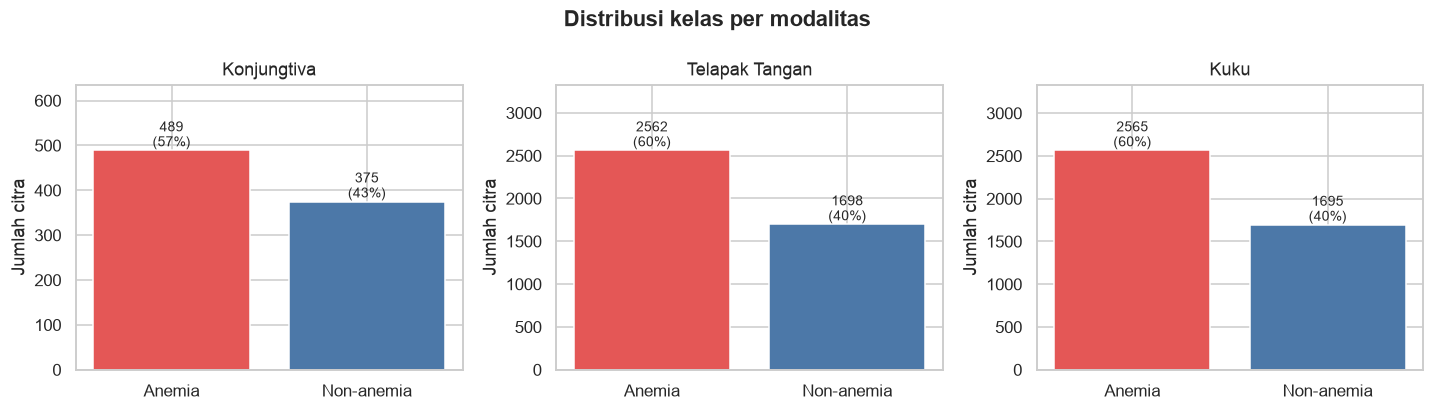

label,Anemia,Non-anemia,Total
source_dataset,,,
"CP-AnemiC (anak, Ghana)",424,286,710
"Eyes-Defy (dewasa, Italia & India)",65,89,154
Total,489,375,864


In [2]:
rows = []
for m, d in dfs.items():
    ic = d["label"].value_counts()
    tanpa_sufiks = (~d["filename"].str.contains(r"\(\d+\)")).sum() if "filename" in d else len(d)
    rows.append({"Modalitas": MOD[m], "Total citra": len(d),
                 "Citra asli (tanpa sufiks augmentasi)": tanpa_sufiks,
                 "Grup subjek (unit split)": d["subject_id"].nunique(),
                 "Citra per grup subjek": round(len(d) / d["subject_id"].nunique(), 2),
                 "Anemia": ic.get("Anemia", 0), "Non-anemia": ic.get("Non-anemia", 0),
                 "% Anemia": round(100 * ic.get("Anemia", 0) / len(d), 1)})
ringkas = pd.DataFrame(rows); ringkas.to_csv(TAB / "eda_ringkasan_dataset.csv", index=False)
display(ringkas)

fig, ax = plt.subplots(1, len(MOD), figsize=(4.4 * len(MOD), 3.8), squeeze=False); ax = ax[0]
for a, (m, d) in zip(ax, dfs.items()):
    c = d["label"].value_counts().reindex(HUE)
    a.bar(c.index, c.values, color=[PAL[k] for k in c.index])
    for i, v in enumerate(c.values):
        a.text(i, v, f"{v}\n({v/len(d):.0%})", ha="center", va="bottom", fontsize=9)
    a.set_title(MOD[m]); a.set_ylabel("Jumlah citra"); a.set_ylim(0, c.max() * 1.3)
fig.suptitle("Distribusi kelas per modalitas", fontweight="bold"); fig.tight_layout(); save(fig, "01_distribusi_kelas")

if KONJ in dfs and "source_dataset" in dfs[KONJ]:
    src = pd.crosstab(dfs[KONJ]["source_dataset"].map(SUMBER), dfs[KONJ]["label"], margins=True, margins_name="Total")
    src.to_csv(TAB / "eda_konjungtiva_per_sumber.csv"); display(src)

## 2. Pembagian train / val / test & cek kebocoran data

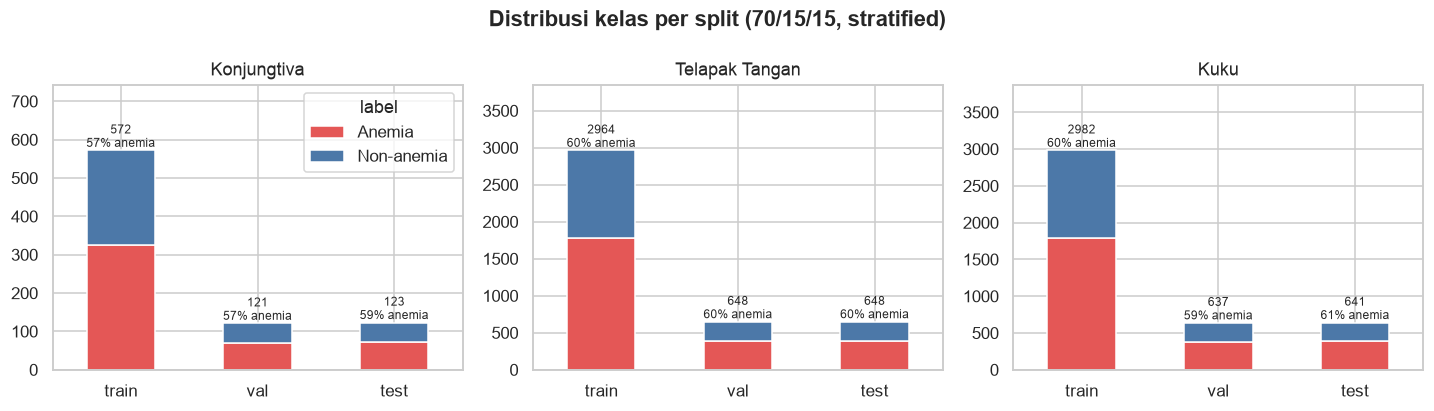

Konjungtiva     grup subjek yang muncul di >1 split: 0
Telapak Tangan  grup subjek yang muncul di >1 split: 0
Kuku            grup subjek yang muncul di >1 split: 0


In [3]:
ORDER = ["train", "val", "test"]; rows = []
fig, ax = plt.subplots(1, len(MOD), figsize=(4.4 * len(MOD), 3.8), squeeze=False); ax = ax[0]
for a, (m, d) in zip(ax, dfs.items()):
    ct = pd.crosstab(d["split"], d["label"]).reindex(ORDER)[HUE]
    ct.plot(kind="bar", stacked=True, ax=a, color=[PAL[h] for h in HUE], legend=(a is ax[0]), rot=0)
    for i, s in enumerate(ORDER):
        tot = int(ct.loc[s].sum())
        a.text(i, tot, f"{tot}\n{ct.loc[s,'Anemia']/tot:.0%} anemia", ha="center", va="bottom", fontsize=8)
        rows.append({"Modalitas": MOD[m], "Split": s, "Anemia": int(ct.loc[s, "Anemia"]),
                     "Non-anemia": int(ct.loc[s, "Non-anemia"]), "Total": tot})
    a.set_title(MOD[m]); a.set_xlabel(""); a.set_ylim(0, ct.sum(axis=1).max() * 1.3)
fig.suptitle("Distribusi kelas per split (70/15/15, stratified)", fontweight="bold"); fig.tight_layout(); save(fig, "02_distribusi_split")
pd.DataFrame(rows).to_csv(TAB / "eda_split.csv", index=False)

for m, d in dfs.items():
    g = {s: set(d.loc[d["split"] == s, "subject_id"]) for s in ORDER}
    bocor = len((g["train"] & g["val"]) | (g["train"] & g["test"]) | (g["val"] & g["test"]))
    print(f"{MOD[m]:15s} grup subjek yang muncul di >1 split: {bocor}")

## 3. Augmentasi bawaan dataset (palm & kuku)
Dataset palm dan kuku sudah diaugmentasi oleh penyusunnya (710 → 4.260). Grafik ini menunjukkan berapa citra yang berasal dari satu grup subjek.

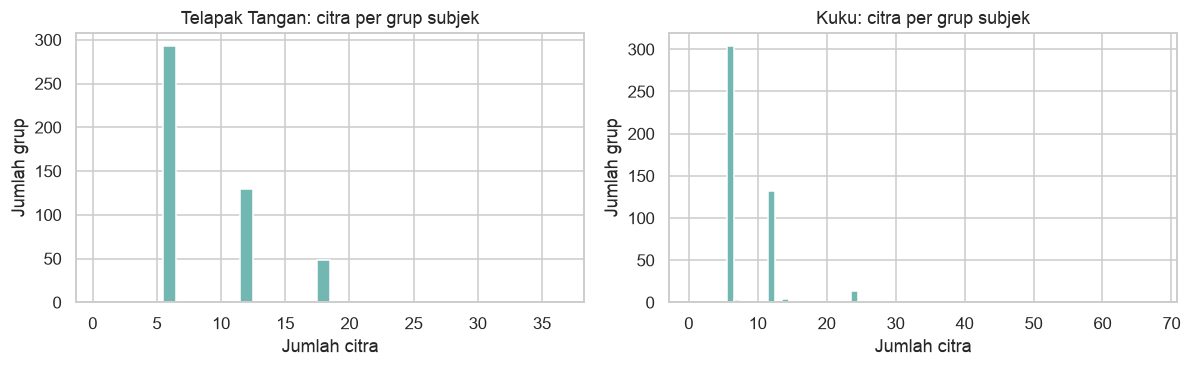

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
for a, m in zip(ax, ["palm", "fingernail"]):
    cnt = dfs[m].groupby("subject_id").size()
    a.hist(cnt, bins=range(1, cnt.max() + 2), color="#72B7B2", edgecolor="white", align="left")
    a.set_title(f"{MOD[m]}: citra per grup subjek"); a.set_xlabel("Jumlah citra"); a.set_ylabel("Jumlah grup")
fig.tight_layout(); save(fig, "03_citra_per_subjek")

## 4. Resolusi & format citra

In [5]:
res = []
for m, d in dfs.items():
    for p in d.sample(min(300, len(d)), random_state=42)["image_path"]:
        with Image.open(p) as im: res.append({"Modalitas": MOD[m], "w": im.size[0], "h": im.size[1], "mode": im.mode})
res = pd.DataFrame(res)
resolusi = res.groupby("Modalitas").agg(
    lebar_min=("w", "min"), lebar_median=("w", "median"), lebar_max=("w", "max"),
    tinggi_min=("h", "min"), tinggi_median=("h", "median"), tinggi_max=("h", "max"),
    mode_warna=("mode", lambda x: ", ".join(sorted(set(x)))))
resolusi.to_csv(TAB / "eda_resolusi.csv"); display(resolusi)
print("Semua citra di-resize ke 224x224 sebelum masuk model.")

,lebar_min,lebar_median,lebar_max,tinggi_min,tinggi_median,tinggi_max,mode_warna
Modalitas,,,,,,,
Konjungtiva,79,252.5,2988,34,96.5,3984,"RGB, RGBA"
Kuku,25,75.0,171,21,67.0,216,RGBA
Telapak Tangan,73,183.5,751,73,186.0,583,RGBA


Semua citra di-resize ke 224x224 sebelum masuk model.


## 5. Contoh citra

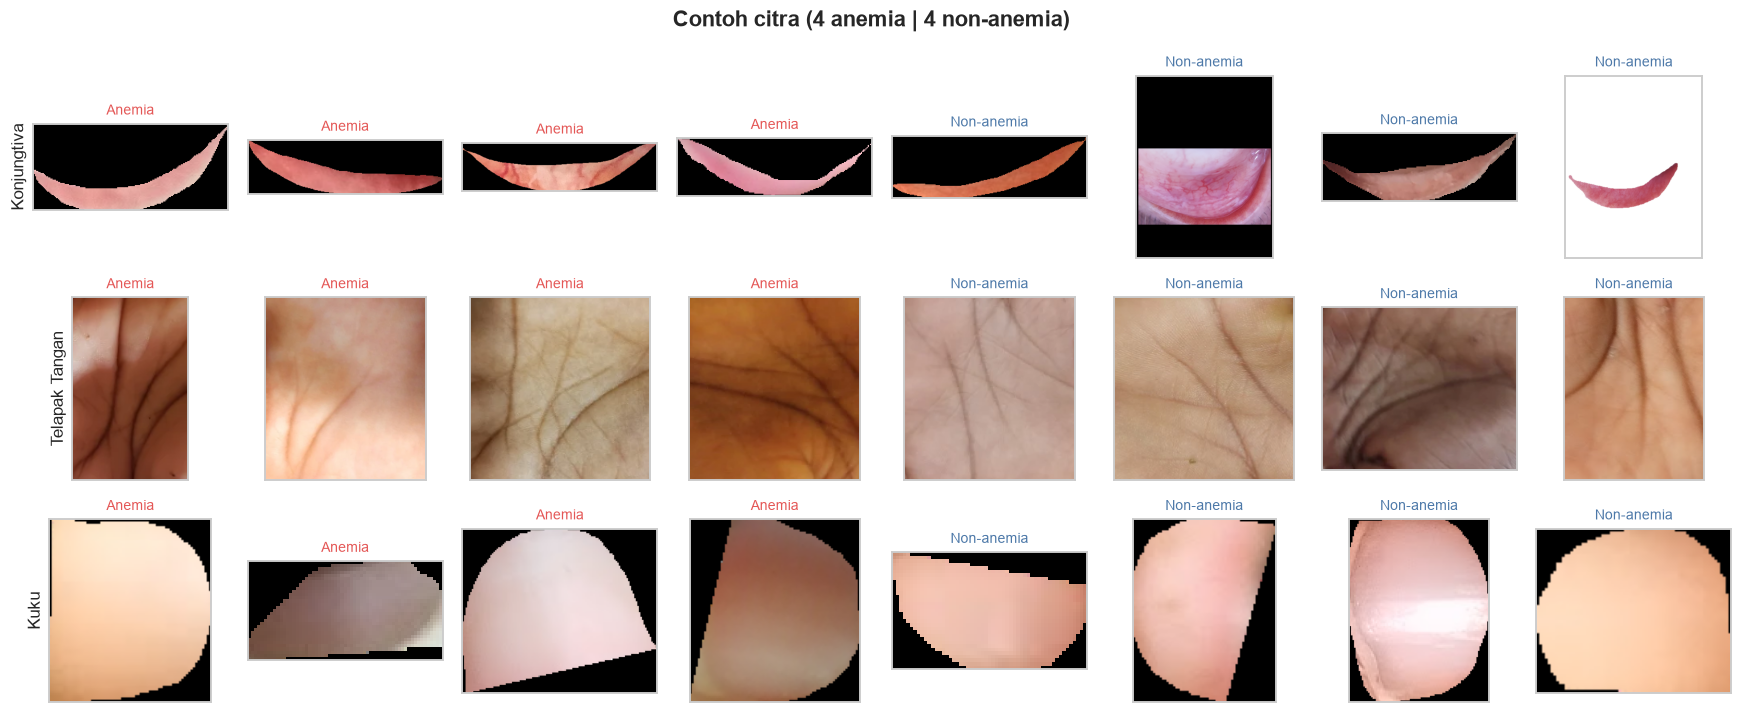

In [6]:
fig, ax = plt.subplots(len(MOD), 8, figsize=(16, 2.2 * len(MOD)), squeeze=False)
for r, (m, d) in enumerate(dfs.items()):
    u = d.drop_duplicates("subject_id")
    picks = pd.concat([u[u.who_anemic == 1].sample(4, random_state=1), u[u.who_anemic == 0].sample(4, random_state=1)])
    for c, (_, row) in enumerate(picks.iterrows()):
        a = ax[r, c]; a.imshow(Image.open(row.image_path).convert("RGB")); a.grid(False)
        a.set_xticks([]); a.set_yticks([]); a.set_title(row.label, fontsize=9, color=PAL[row.label])
    ax[r, 0].set_ylabel(MOD[m], fontsize=11)
fig.suptitle("Contoh citra (4 anemia | 4 non-anemia)", fontweight="bold"); fig.tight_layout(); save(fig, "04_contoh_citra")

## 6. Analisis warna: apakah kepucatan terlihat?
Satu citra per grup subjek (supaya hasil augmentasi tidak dihitung berulang). Piksel gelap (latar belakang) dibuang. Uji Mann-Whitney U: p < 0,05 artinya warna anemia vs non-anemia berbeda signifikan.

,Modalitas,Fitur,Median anemia,Median non-anemia,p-value,Beda signifikan?
0,Konjungtiva,a* CIELAB (kemerahan),26.374,28.269,0.000520,Ya
1,Konjungtiva,Erythema index,19.957,21.138,0.012000,Ya
2,Konjungtiva,Saturasi HSV,0.440,0.443,0.110000,Tidak
3,Konjungtiva,Kecerahan HSV,0.731,0.743,0.680000,Tidak
4,Telapak Tangan,a* CIELAB (kemerahan),13.288,15.316,0.000001,Ya
5,Telapak Tangan,Erythema index,11.249,13.517,0.000170,Ya
6,Telapak Tangan,Saturasi HSV,0.386,0.398,0.033000,Ya
7,Telapak Tangan,Kecerahan HSV,0.700,0.712,0.170000,Tidak
8,Kuku,a* CIELAB (kemerahan),12.547,11.661,0.730000,Tidak
9,Kuku,Erythema index,8.927,9.080,0.600000,Tidak


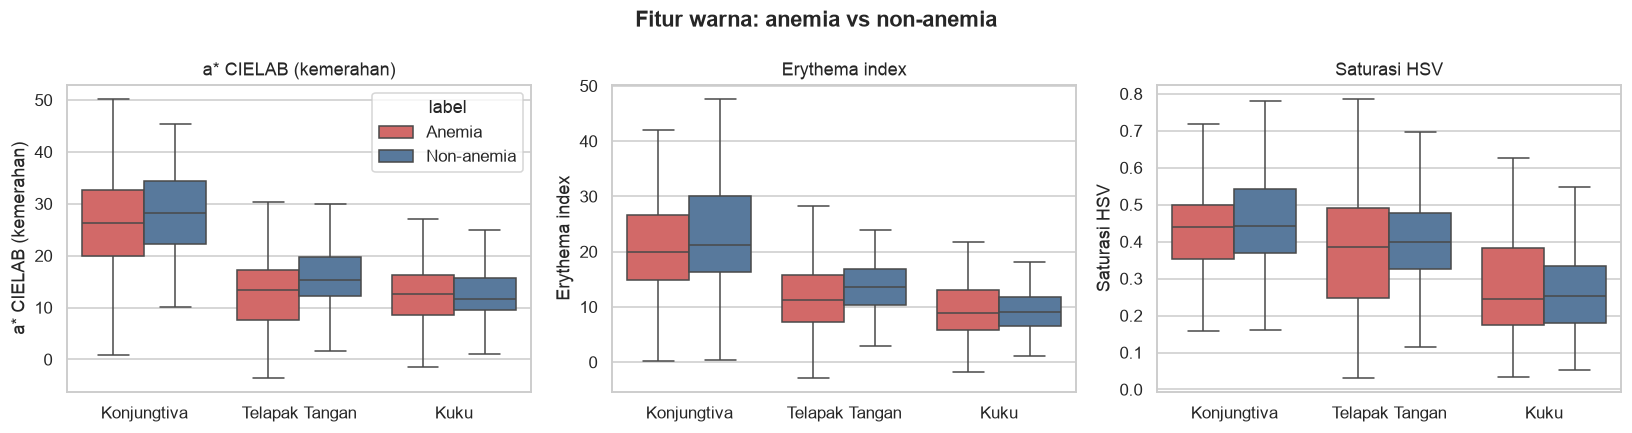

In [7]:
def fitur_warna(p):
    rgb = np.asarray(Image.open(p).convert("RGB").resize((224, 224)))
    hsv = cv2.cvtColor(rgb, cv2.COLOR_RGB2HSV); lab = cv2.cvtColor(rgb, cv2.COLOR_RGB2LAB).astype(float)
    mask = hsv[..., 2] > 25
    if mask.sum() < 100: mask = np.ones(mask.shape, bool)
    R, G, B = (rgb[..., i][mask].astype(float).mean() for i in range(3))
    return {"a* CIELAB (kemerahan)": lab[..., 1][mask].mean() - 128,
            "Erythema index": 100 * (np.log10(R + 1) - np.log10(G + 1)),
            "Saturasi HSV": hsv[..., 1][mask].mean() / 255,
            "Kecerahan HSV": hsv[..., 2][mask].mean() / 255}

feat = []
for m, d in dfs.items():
    for _, row in d.drop_duplicates("subject_id").iterrows():
        f = fitur_warna(row.image_path); f.update(Modalitas=MOD[m], label=row.label); feat.append(f)
feat = pd.DataFrame(feat); feat.to_csv(TAB / "eda_fitur_warna.csv", index=False)
FITUR = [c for c in feat.columns if c not in ("Modalitas", "label")]

uji = []
for mm, g in feat.groupby("Modalitas", sort=False):
    for f in FITUR:
        a_, n_ = g.loc[g.label == "Anemia", f], g.loc[g.label == "Non-anemia", f]
        p = mannwhitneyu(a_, n_).pvalue
        uji.append({"Modalitas": mm, "Fitur": f, "Median anemia": round(a_.median(), 3),
                    "Median non-anemia": round(n_.median(), 3), "p-value": float(f"{p:.2g}"),
                    "Beda signifikan?": "Ya" if p < 0.05 else "Tidak"})
uji = pd.DataFrame(uji); uji.to_csv(TAB / "eda_uji_warna.csv", index=False); display(uji)

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
for a, f in zip(ax, ["a* CIELAB (kemerahan)", "Erythema index", "Saturasi HSV"]):
    sns.boxplot(data=feat, x="Modalitas", y=f, hue="label", hue_order=HUE, palette=PAL, ax=a, showfliers=False)
    a.set_xlabel(""); a.set_title(f)
    if a is not ax[0]: a.get_legend().remove()
fig.suptitle("Fitur warna: anemia vs non-anemia", fontweight="bold"); fig.tight_layout(); save(fig, "05_fitur_warna")

## 7. Data klinis konjungtiva (Hb, keparahan, sumber/usia)
Batas anemia WHO: anak < 11 g/dL (CP-AnemiC), dewasa < 12 (perempuan) / < 13 (laki-laki) g/dL (Eyes-Defy).

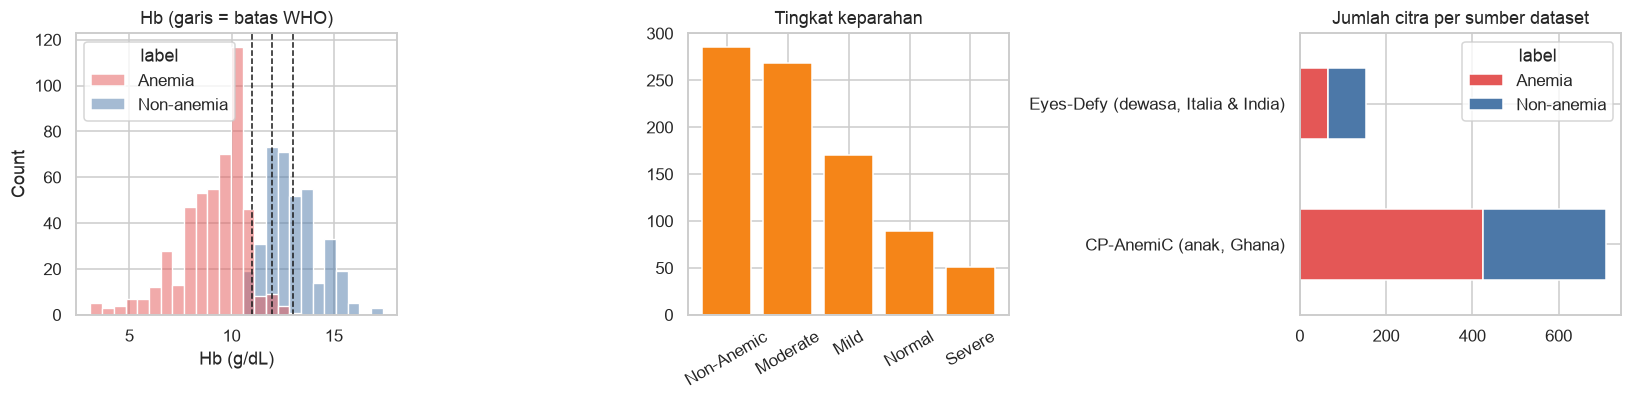

count   mean   std   min    25%    50%    75%  \
source_dataset label                                                       
cp_anemic      Anemia      424.0   8.89  1.61   3.1   8.00   9.20  10.10   
               Non-anemia  286.0  12.53  0.96  11.0  11.90  12.45  13.18   
eyes_defy      Anemia       65.0  10.38  1.41   7.0   9.35  10.50  11.50   
               Non-anemia   89.0  14.42  1.17  12.0  13.62  14.70  15.30   

                             max  
source_dataset label              
cp_anemic      Anemia      10.93  
               Non-anemia  15.00  
eyes_defy      Anemia      12.90  
               Non-anemia  17.40

gender
Male      404
Female    306
M          92
F          62
Name: Jumlah per gender, dtype: int64

In [8]:
if KONJ not in dfs:
    print("Konjungtiva tidak dipakai di notebook ini, bagian 7 dilewati.")
else:
    cp = dfs[KONJ].copy()
    cp["hb"] = pd.to_numeric(cp["hb"], errors="coerce")
    fig, ax = plt.subplots(1, 3, figsize=(15, 3.8))
    sns.histplot(data=cp, x="hb", hue="label", hue_order=HUE, palette=PAL, bins=25, ax=ax[0])
    for t in ([11, 12, 13] if "source_dataset" in cp else [11]): ax[0].axvline(t, ls="--", c="k", lw=1)
    ax[0].set_title("Hb (garis = batas WHO)"); ax[0].set_xlabel("Hb (g/dL)")
    sev = cp["severity"].astype(str).value_counts(); ax[1].bar(sev.index, sev.values, color="#F58518")
    ax[1].set_title("Tingkat keparahan"); ax[1].tick_params(axis="x", rotation=30)
    if "source_dataset" in cp:
        pd.crosstab(cp["source_dataset"].map(SUMBER), cp["label"])[HUE].plot(kind="barh", stacked=True, ax=ax[2], color=[PAL[h] for h in HUE])
        ax[2].set_title("Jumlah citra per sumber dataset"); ax[2].set_ylabel("")
    else:
        cp["age_months"] = pd.to_numeric(cp["age_months"], errors="coerce")
        sns.histplot(data=cp, x="age_months", hue="label", hue_order=HUE, palette=PAL, bins=20, ax=ax[2]); ax[2].set_title("Usia (bulan)")
    fig.tight_layout(); save(fig, "06_konjungtiva_klinis")
    grp = ["source_dataset", "label"] if "source_dataset" in cp else ["label"]
    klinis = cp.groupby(grp)["hb"].describe().round(2); display(klinis); klinis.to_csv(TAB / "eda_konjungtiva_klinis.csv")
    display(cp["gender"].value_counts().rename("Jumlah per gender"))

## 8. Profil model: jumlah parameter, ukuran, latensi
Angka ini yang dipakai di slide Model Development (menggantikan klaim ~5,3 juta parameter, ~20 MB, ~300 ms).

In [9]:
import torch
from src.models.efficientnet_cbam import EfficientNetB0_CBAM
model = EfficientNetB0_CBAM(num_classes=2, pretrained=False).eval()
n_param = sum(p.numel() for p in model.parameters())
buf = io.BytesIO(); torch.save(model.state_dict(), buf); size_mb = buf.tell() / 1e6

def latensi(dev, n=100):
    m = model.to(dev); x = torch.randn(1, 3, 224, 224, device=dev)
    sync = torch.mps.synchronize if dev == "mps" else (lambda: None)
    with torch.no_grad():
        for _ in range(10): m(x); sync()
        t = []
        for _ in range(n):
            s = time.perf_counter(); m(x); sync(); t.append((time.perf_counter() - s) * 1000)
    return np.median(t), np.percentile(t, 95)

profil = [{"Metrik": "Jumlah parameter", "Nilai": f"{n_param/1e6:.2f} juta"},
          {"Metrik": "Ukuran bobot (float32)", "Nilai": f"{size_mb:.1f} MB"}]
for dev in ["cpu"] + (["mps"] if torch.backends.mps.is_available() else []):
    med, p95 = latensi(dev)
    profil.append({"Metrik": f"Latensi 1 citra di {dev.upper()} (median / p95)", "Nilai": f"{med:.1f} ms / {p95:.1f} ms"})
profil = pd.DataFrame(profil); profil.to_csv(TAB / "profil_model.csv", index=False); display(profil)
print("Diukur di MacBook Air (bukan HP). Sebut perangkatnya di slide.")

,Metrik,Nilai
0,Jumlah parameter,4.22 juta
1,Ukuran bobot (float32),17.2 MB
2,Latensi 1 citra di CPU (median / p95),83.6 ms / 92.5 ms
3,Latensi 1 citra di MPS (median / p95),5.6 ms / 6.0 ms


Diukur di MacBook Air (bukan HP). Sebut perangkatnya di slide.


## 9. Evaluasi gabungan 3 model (test set)
Memuat `checkpoints/<modalitas>/best_model.pth` yang **terbaru**. Interval kepercayaan 95% dihitung dengan bootstrap (1.000×) karena test set kecil, terutama konjungtiva.

In [10]:
from torch.utils.data import DataLoader
from sklearn.metrics import confusion_matrix, roc_auc_score, roc_curve, f1_score, precision_score
from src.data.dataset import get_dataset
dev = "mps" if torch.backends.mps.is_available() else "cpu"
rng = np.random.default_rng(42)

def ci(y, p, fn, B=1000):
    v = []
    for _ in range(B):
        i = rng.integers(0, len(y), len(y))
        if len(set(y[i])) < 2: continue
        v.append(fn(y[i], p[i]))
    return np.percentile(v, [2.5, 97.5])

hasil, per_sumber, ROC, CM = [], [], {}, {}
for m in MOD:
    ck = torch.load(CHECKPOINTS_DIR / m / "best_model.pth", map_location="cpu", weights_only=False)
    net = EfficientNetB0_CBAM(num_classes=2, pretrained=False); net.load_state_dict(ck["model_state_dict"]); net.to(dev).eval()
    dl = DataLoader(get_dataset(m, split="test"), batch_size=32, shuffle=False, num_workers=0)
    ys, ps, ids = [], [], []
    with torch.no_grad():
        for x, y, sid in dl:
            ps.append(torch.softmax(net(x.to(dev)), 1)[:, 1].cpu().numpy()); ys.append(y.numpy()); ids += list(sid)
    y, p = np.concatenate(ys), np.concatenate(ps); yh = (p >= 0.5).astype(int)
    tn, fp, fn, tp = confusion_matrix(y, yh, labels=[0, 1]).ravel()
    auc_lo, auc_hi = ci(y, p, roc_auc_score)
    f1_lo, f1_hi = ci(y, p, lambda a, b: f1_score(a, (b >= 0.5).astype(int)))
    hasil.append({"Modalitas": MOD[m], "Best epoch": ck.get("epoch"), "n test": len(y),
                  "Accuracy": (tp + tn) / len(y), "Sensitivity": tp / (tp + fn), "Specificity": tn / (tn + fp),
                  "Precision": precision_score(y, yh, zero_division=0), "F1": f1_score(y, yh),
                  "F1 95% CI": f"{f1_lo:.3f}–{f1_hi:.3f}", "AUC": roc_auc_score(y, p), "AUC 95% CI": f"{auc_lo:.3f}–{auc_hi:.3f}"})
    ROC[m] = roc_curve(y, p); CM[m] = np.array([[tn, fp], [fn, tp]])
    if m == "conjunctiva":   # rincian test set gabungan per sumber
        ids = np.array([str(i) for i in ids])
        for pre, nama in [("cp_", "CP-AnemiC"), ("eyes_", "Eyes-Defy")]:
            k = np.char.startswith(ids, pre)
            if k.sum() == 0 or len(set(y[k])) < 2: continue
            yk, pk = y[k], p[k]; hk = (pk >= 0.5).astype(int)
            tn_, fp_, fn_, tp_ = confusion_matrix(yk, hk, labels=[0, 1]).ravel()
            per_sumber.append({"Modalitas": f"  ↳ Konjungtiva: subset {nama}", "n test": int(k.sum()),
                               "Accuracy": (tp_ + tn_) / k.sum(), "Sensitivity": tp_ / (tp_ + fn_), "Specificity": tn_ / (tn_ + fp_),
                               "Precision": precision_score(yk, hk, zero_division=0), "F1": f1_score(yk, hk), "AUC": roc_auc_score(yk, pk)})
hasil = pd.DataFrame(hasil + per_sumber).set_index("Modalitas").round(4)
hasil.to_csv(TAB / "hasil_perbandingan_3_modalitas.csv"); display(hasil)

,Best epoch,n test,Accuracy,Sensitivity,Specificity,Precision,F1,F1 95% CI,AUC,AUC 95% CI
Modalitas,,,,,,,,,,
Konjungtiva,25.0,130,0.7615,0.7838,0.7321,0.7945,0.7891,0.709–0.855,0.8002,0.719–0.873
Telapak Tangan,26.0,648,0.8056,0.7744,0.8527,0.8882,0.8274,0.795–0.856,0.8980,0.873–0.921
Kuku,2.0,641,0.6069,0.7584,0.3730,0.6512,0.7007,0.663–0.731,0.6603,0.622–0.704
↳ Konjungtiva: subset CP-AnemiC,NaN,107,0.7477,0.7812,0.6977,0.7937,0.7874,NaN,0.7914,NaN
↳ Konjungtiva: subset Eyes-Defy,NaN,23,0.8261,0.8000,0.8462,0.8000,0.8000,NaN,0.8385,NaN


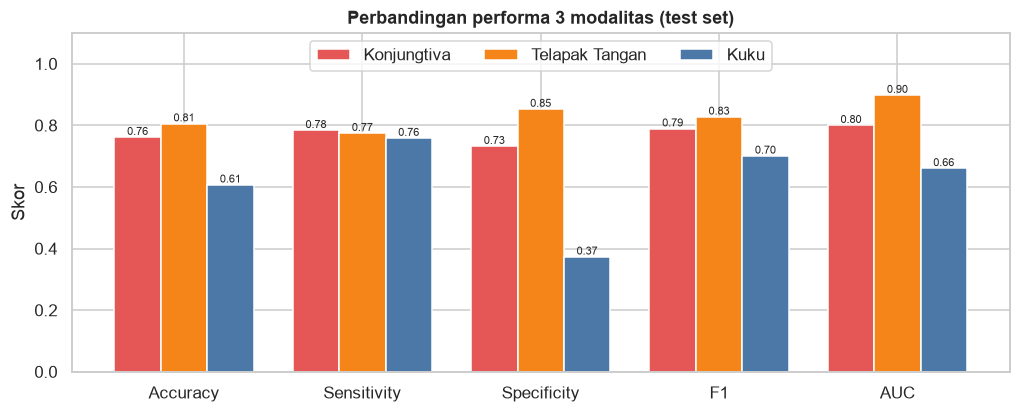

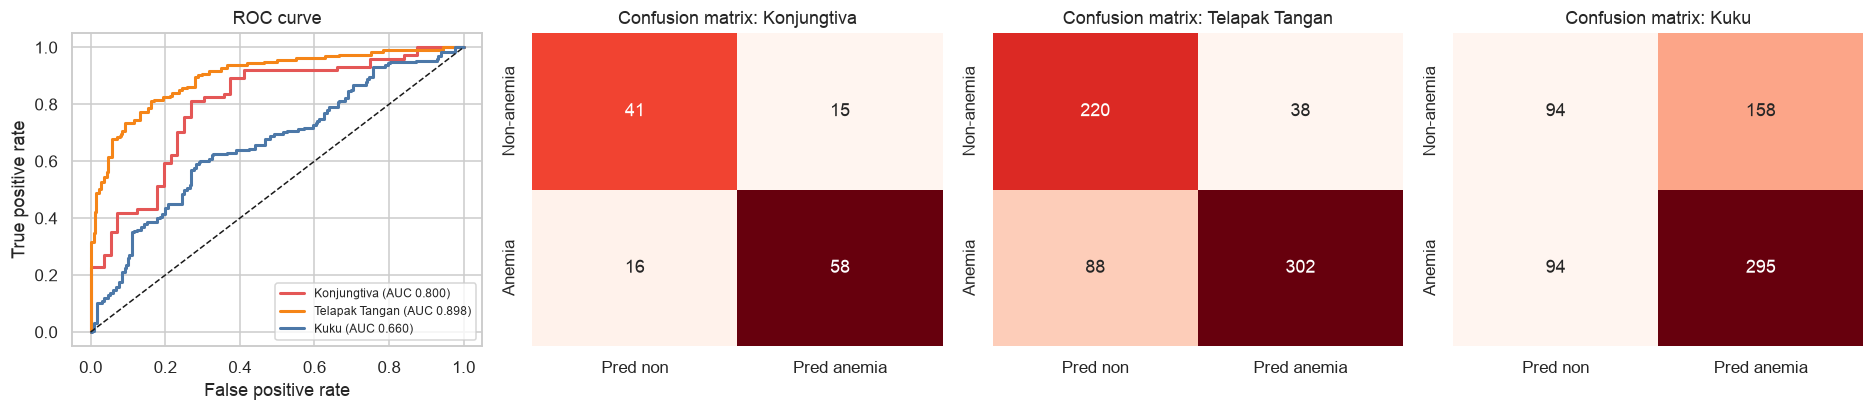

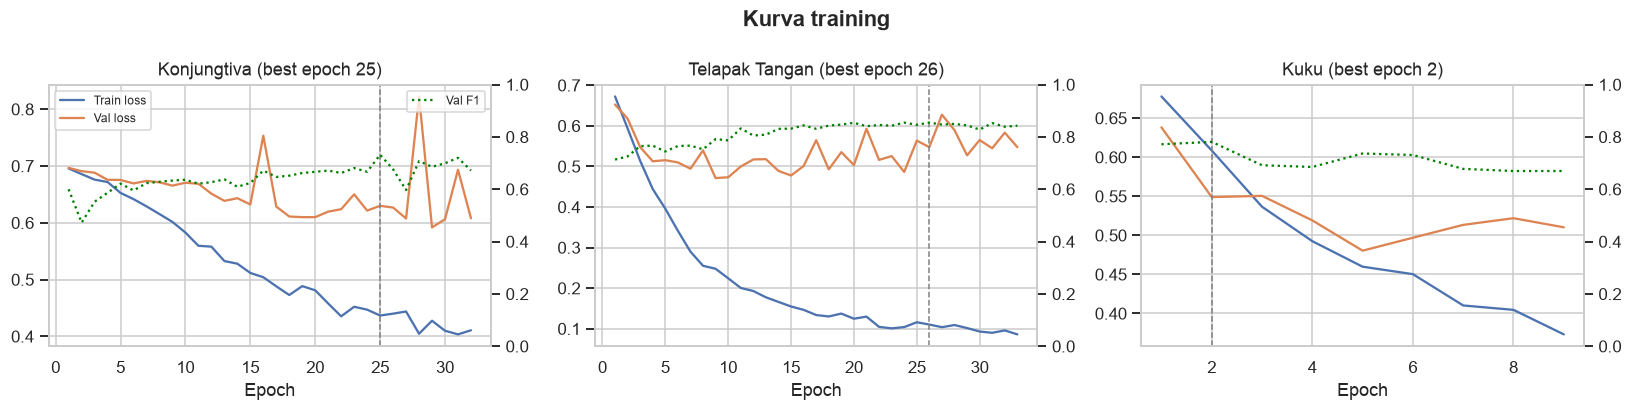

Grafik: /Users/cindypermatasarikhoeniawan/DeepLearning_Anemia/results/figures/eda
Tabel: /Users/cindypermatasarikhoeniawan/DeepLearning_Anemia/results/tables


In [11]:
METRIK = ["Accuracy", "Sensitivity", "Specificity", "F1", "AUC"]
WARNA = {"Konjungtiva": "#E45756", "Telapak Tangan": "#F58518", "Kuku": "#4C78A8"}
fig, ax = plt.subplots(figsize=(11, 4))
x = np.arange(len(METRIK)); w = 0.26
for i, (mod, row) in enumerate(hasil.loc[list(MOD.values())].iterrows()):
    b = ax.bar(x + (i - (len(MOD) - 1) / 2) * w, row[METRIK].astype(float), w, label=mod, color=WARNA[mod])
    ax.bar_label(b, fmt="%.2f", fontsize=7)
ax.set_xticks(x, METRIK); ax.set_ylim(0, 1.1); ax.legend(ncol=3, loc="upper center"); ax.set_ylabel("Skor")
ax.set_title("Perbandingan performa 3 modalitas (test set)", fontweight="bold"); save(fig, "07_perbandingan_metrik")

fig, ax = plt.subplots(1, len(MOD) + 1, figsize=(4.3 * (len(MOD) + 1), 3.9))
for m, (fpr, tpr, _) in ROC.items():
    ax[0].plot(fpr, tpr, color=WARNA[MOD[m]], lw=2, label=f"{MOD[m]} (AUC {hasil.loc[MOD[m], 'AUC']:.3f})")
ax[0].plot([0, 1], [0, 1], "k--", lw=1); ax[0].set_xlabel("False positive rate"); ax[0].set_ylabel("True positive rate")
ax[0].set_title("ROC curve"); ax[0].legend(fontsize=8, loc="lower right")
for a, m in zip(ax[1:], MOD):
    sns.heatmap(CM[m], annot=True, fmt="d", cmap="Reds", cbar=False, ax=a,
                xticklabels=["Pred non", "Pred anemia"], yticklabels=["Non-anemia", "Anemia"])
    a.set_title(f"Confusion matrix: {MOD[m]}")
fig.tight_layout(); save(fig, "08_roc_confusion")

fig, ax = plt.subplots(1, len(MOD), figsize=(5 * len(MOD), 3.8), squeeze=False); ax = ax[0]
for a, m in zip(ax, MOD):
    h = pd.read_csv(LOGS_DIR / f"{m}_training_history.csv")
    a.plot(h.epoch, h.train_loss, label="Train loss"); a.plot(h.epoch, h.val_loss, label="Val loss")
    a2 = a.twinx(); a2.plot(h.epoch, h.val_f1, color="green", ls=":", label="Val F1"); a2.set_ylim(0, 1); a2.grid(False)
    best = h.loc[h.val_f1.idxmax(), "epoch"]; a.axvline(best, color="grey", ls="--", lw=1)
    a.set_title(f"{MOD[m]} (best epoch {best})"); a.set_xlabel("Epoch")
    if a is ax[0]: a.legend(loc="upper left", fontsize=8); a2.legend(loc="upper right", fontsize=8)
fig.suptitle("Kurva training", fontweight="bold"); fig.tight_layout(); save(fig, "09_kurva_training")
print("Grafik:", FIG); print("Tabel:", TAB)